# CovariateExamples

Defining and plotting Covariate objects.

Python port of the MATLAB `CovariateExamples` helpfile (`helpfiles/CovariateExamples.m`).

In [ ]:
from pathlib import Path
import sys
REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from nstat import SignalObj, Covariate, CovColl, Events, nspikeTrain, nstColl
from nstat.notebook_figures import FigureTracker
np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="CovariateExamples", output_root=OUTPUT_ROOT, expected_count=2)


In [ ]:
# SECTION 1: Test the Cov class
# Covariates are just like signals with a mean and a standard deviation.
# They have two representations, the default (original representation) and
# a zero-mean representation. This section is prose-only in the MATLAB
# helpfile; no calls are executed here.


In [ ]:
# SECTION 2: Example 1: Using Covariates
# Create some data — mirrors MATLAB lines: t, x=exp(-t), y=sin(2*pi*t),
# z=(-y)^3, fx=abs(y), fy=abs(y)^2.
t = np.arange(0, 5 + 0.01, 0.01)
x = np.exp(-t)
y = np.sin(2 * np.pi * t)
z = (-y) ** 3
fx = np.abs(y)
fy = np.abs(y) ** 2


In [ ]:
# SECTION 3: (untitled section)
# MATLAB: define labels and construct the `force` and `position` Covariate objects.
dLabels1 = ["f_x", "f_y"]
dLabels2 = ["x", "y", "z"]
force = Covariate(t, np.vstack([fx, fy]).T, "Force", "time", "s", "N", dLabels1)
position = Covariate(t, np.vstack([x, y, z]).T, "Position", "time", "s", "cm", dLabels2)


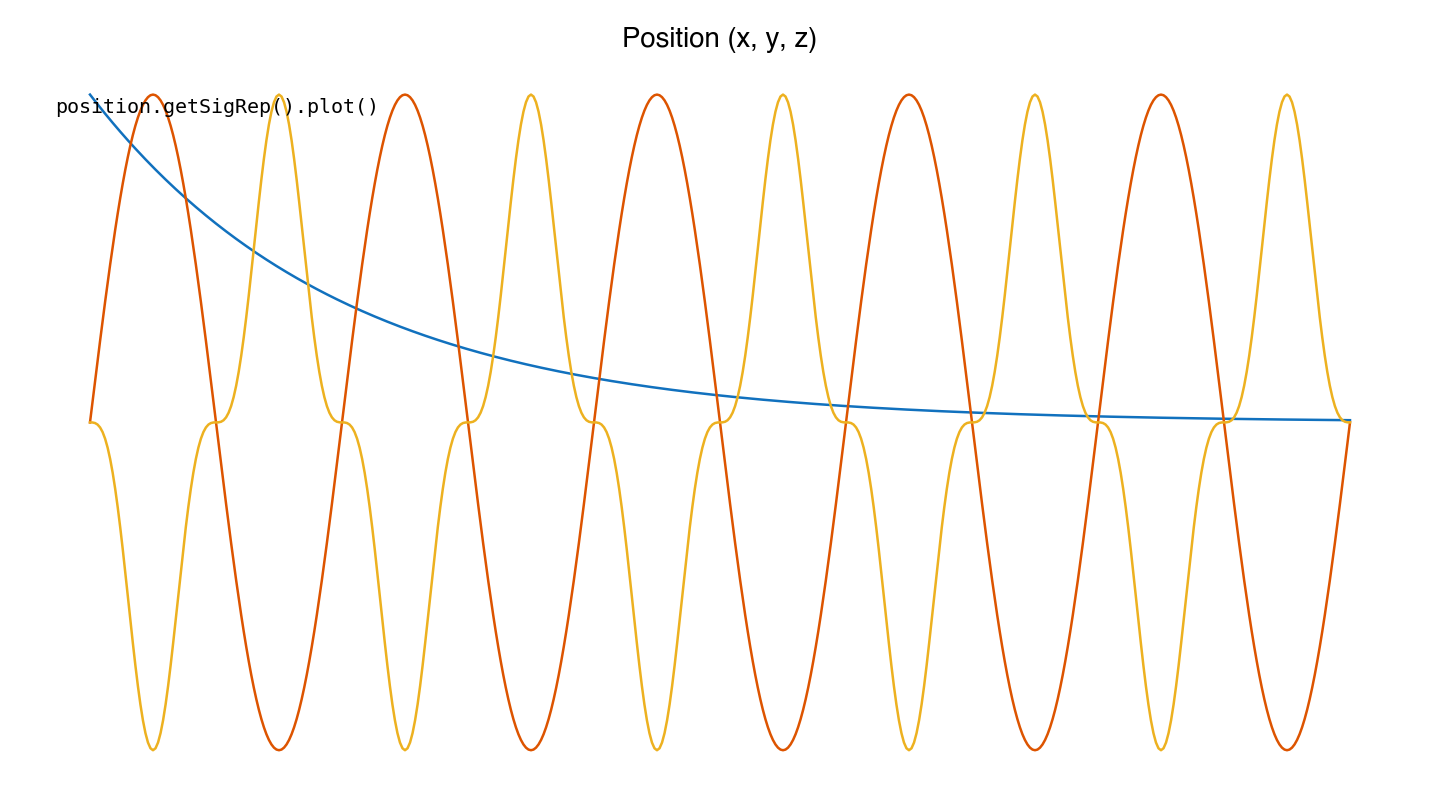

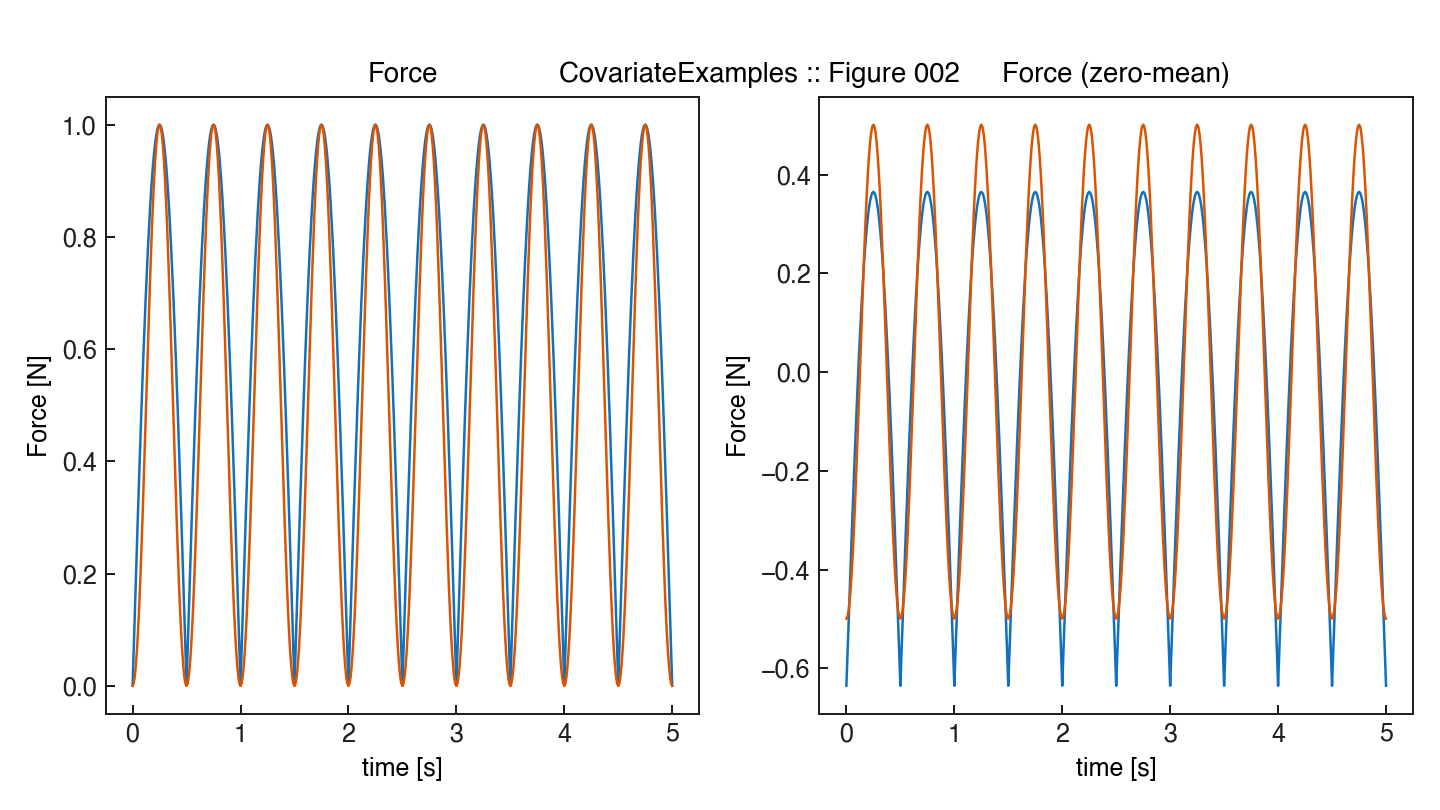

In [ ]:
# SECTION 4: (untitled section)
# MATLAB: plot the covariates and change their properties.
#   position.getSigRep.plot('all',plotProps);
#   figure; subplot(1,2,1); force.getSigRep.plot('all',plotPropsForce);
#   subplot(1,2,2); force.getSigRep('zero-mean').plot('all',plotPropsForce);
__tracker.new_figure("position.getSigRep().plot()")
position.getSigRep().plot()
plt.title("Position (x, y, z)")
plt.tight_layout()

__tracker.new_figure("force: raw vs zero-mean")
plt.subplot(1, 2, 1)
force.getSigRep().plot()
plt.title("Force")
plt.subplot(1, 2, 2)
force.getSigRep("zero-mean").plot()
plt.title("Force (zero-mean)")
plt.tight_layout()
__tracker.finalize()
